# 📈 Chương 5: Các Phương Pháp Cổ Điển (ARIMA, SARIMA, Exponential Smoothing)
## Advanced Data Science - Session 5

---

**Mục tiêu chương này:**
- Hiểu và áp dụng Exponential Smoothing (SES, Holt, Holt-Winters)
- Nắm vững ARIMA: AR, MA, ARMA, ARIMA
- Mở rộng sang SARIMA cho dữ liệu seasonal
- Biết cách đánh giá model (MAE, RMSE, MAPE, AIC, BIC)
- Thực hành forecast trên dữ liệu thực

## 5.1 Exponential Smoothing

### 🎯 Ý tưởng:
Quan sát **gần** ảnh hưởng **nhiều hơn** quan sát xa → Gán trọng số giảm dần theo hàm mũ.

### A. Simple Exponential Smoothing (SES)
**Dùng khi:** Không có trend, không có seasonality

**Công thức:** Ŷ_{t+1} = α·Y_t + (1-α)·Ŷ_t
- **α gần 1:** Tin tưởng giá trị mới nhất (phản ứng nhanh)
- **α gần 0:** Tin tưởng lịch sử dài hạn (phản ứng chậm)

Ví dụ: Nếu α = 0.3, dự đoán = 30% giá trị mới nhất + 70% dự đoán cũ

### B. Holt's Linear Trend
**Dùng khi:** Có trend nhưng KHÔNG có seasonality

Thêm thành phần trend vào SES:
- Level: l_t = α·Y_t + (1-α)·(l_{t-1} + b_{t-1})
- Trend: b_t = β·(l_t - l_{t-1}) + (1-β)·b_{t-1}

### C. Holt-Winters (Triple Exponential Smoothing)
**Dùng khi:** Có CẢ trend VÀ seasonality

Thêm 3 thành phần: Level + Trend + Seasonality
- **Additive:** Biên độ seasonal cố định
- **Multiplicative:** Biên độ seasonal tỷ lệ theo level

## 5.2 ARIMA

### ARIMA(p, d, q):
- **p (AR):** Số lag của Y (AutoRegressive)
- **d:** Số lần differencing
- **q (MA):** Số lag của error (Moving Average)

### Ví dụ trực quan:

**AR(1):** *"Giá hôm nay = 0.8 × Giá hôm qua + nhiễu"*
```
Y_t = φ₁·Y_{t-1} + ε_t
```

**MA(1):** *"Giá hôm nay = Trung bình + 0.5 × Sai số hôm qua"*
```
Y_t = μ + ε_t + θ₁·ε_{t-1}
```

**ARIMA(1,1,1):** *"Sự thay đổi giá = 0.8 × Thay đổi hôm qua + 0.5 × Sai số hôm qua + nhiễu"*

## 5.3 SARIMA

**SARIMA(p,d,q)(P,D,Q)_m:**
- (p,d,q): Non-seasonal part
- (P,D,Q): Seasonal part
- m: Seasonal period (12 cho monthly, 7 cho daily/weekly)

Ví dụ: SARIMA(1,1,1)(1,1,1)₁₂ cho doanh số monthly

---
## 🔬 Phần Thực Hành
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Hàm đánh giá
def evaluate(actual, predicted, model_name=''):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'📊 {model_name:25s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print('✅ Import thành công!')

✅ Import thành công!


### 📝 Ví dụ 1: Simple Exponential Smoothing

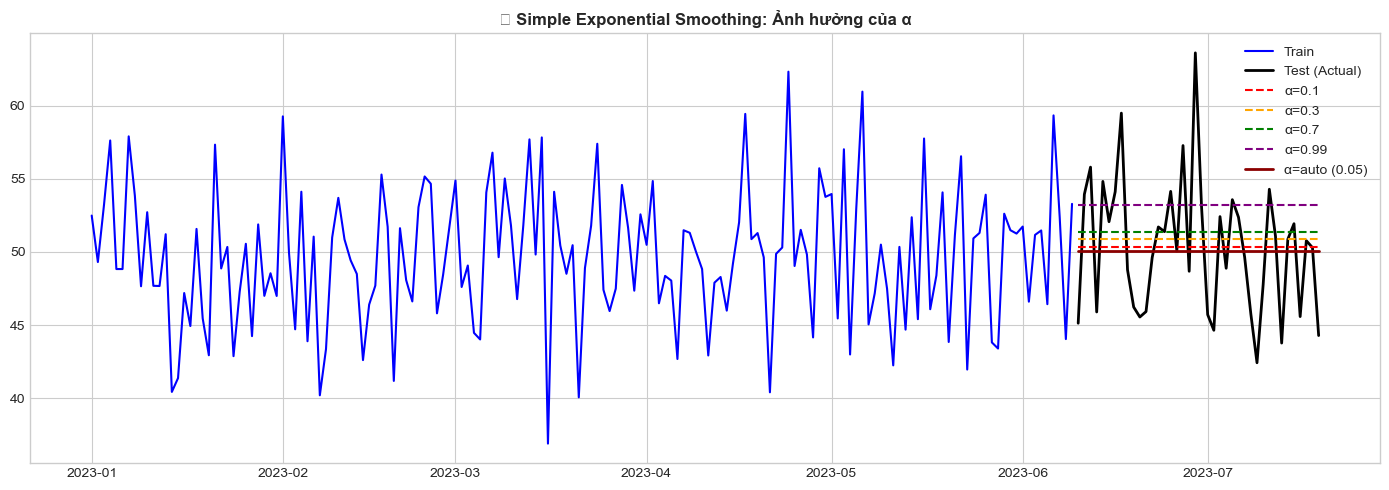

💡 SES dự đoán FLAT LINE (hằng số) cho tương lai
💡 α nhỏ → Dự đoán ổn định hơn (tin lịch sử)
💡 α lớn → Dự đoán phản ứng nhanh (tin giá trị mới nhất)


In [2]:
# Tạo dữ liệu không có trend, không seasonality
np.random.seed(42)
n = 200
y = 50 + np.random.normal(0, 5, n)
dates = pd.date_range('2023-01-01', periods=n, freq='D')
data = pd.Series(y, index=dates)

# Train/Test split
train = data[:160]
test = data[160:]

# Fit SES với các alpha khác nhau
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='blue')
ax.plot(test.index, test, label='Test (Actual)', color='black', linewidth=2)

alphas = [0.1, 0.3, 0.7, 0.99]
colors = ['red', 'orange', 'green', 'purple']

for alpha, color in zip(alphas, colors):
    model = SimpleExpSmoothing(train).fit(smoothing_level=alpha, optimized=False)
    forecast = model.forecast(len(test))
    ax.plot(test.index, forecast, label=f'α={alpha}', color=color, linestyle='--')

# Auto optimized
model_opt = SimpleExpSmoothing(train).fit(optimized=True)
forecast_opt = model_opt.forecast(len(test))
ax.plot(test.index, forecast_opt, label=f'α=auto ({model_opt.params["smoothing_level"]:.2f})', 
        color='darkred', linewidth=2)

ax.legend()
ax.set_title('📊 Simple Exponential Smoothing: Ảnh hưởng của α', fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 SES dự đoán FLAT LINE (hằng số) cho tương lai')
print('💡 α nhỏ → Dự đoán ổn định hơn (tin lịch sử)')
print('💡 α lớn → Dự đoán phản ứng nhanh (tin giá trị mới nhất)')

### 📝 Ví dụ 2: Holt's Linear Trend

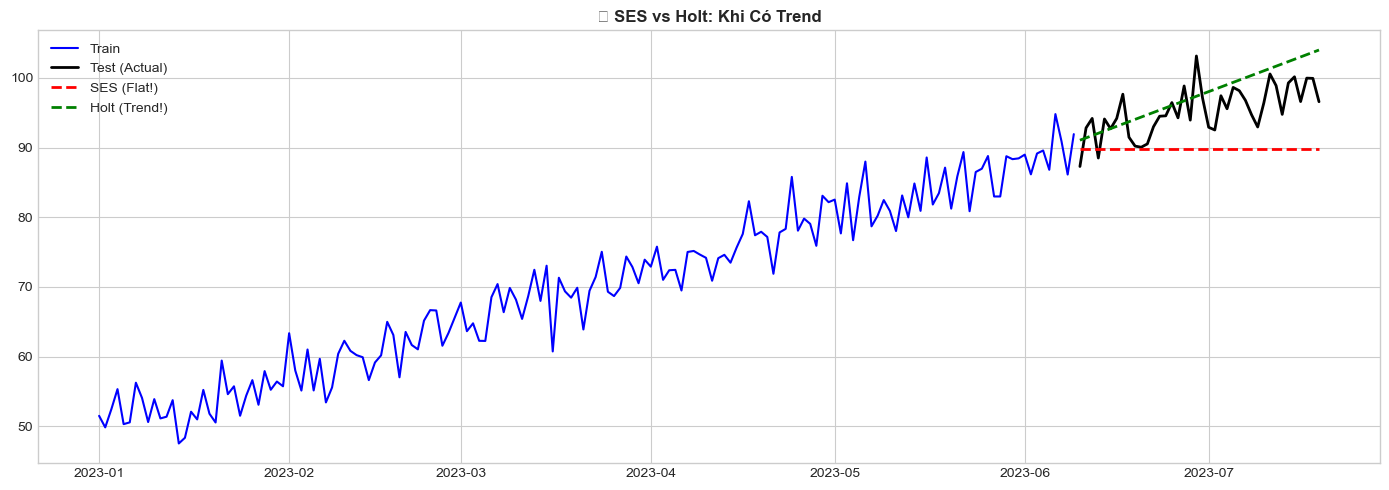


📊 Đánh giá:
📊 SES                       | MAE: 5.75 | RMSE: 6.57 | MAPE: 5.93%
📊 Holt                      | MAE: 3.19 | RMSE: 3.78 | MAPE: 3.36%

💡 SES không bắt được trend → Dự đoán flat → SAI!
💡 Holt bắt được trend → Dự đoán tiếp tục trend → ĐÚNG!


In [3]:
# Tạo dữ liệu CÓ trend
np.random.seed(42)
n = 200
trend = np.linspace(50, 100, n)
noise = np.random.normal(0, 3, n)
y = trend + noise
dates = pd.date_range('2023-01-01', periods=n, freq='D')
data = pd.Series(y, index=dates)

train = data[:160]
test = data[160:]

# SES vs Holt
ses_model = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses_model.forecast(len(test))

holt_model = Holt(train).fit(optimized=True)
holt_forecast = holt_model.forecast(len(test))

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='blue')
ax.plot(test.index, test, label='Test (Actual)', color='black', linewidth=2)
ax.plot(test.index, ses_forecast, label='SES (Flat!)', color='red', linestyle='--', linewidth=2)
ax.plot(test.index, holt_forecast, label='Holt (Trend!)', color='green', linestyle='--', linewidth=2)
ax.legend()
ax.set_title('📊 SES vs Holt: Khi Có Trend', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Đánh giá:')
evaluate(test, ses_forecast, 'SES')
evaluate(test, holt_forecast, 'Holt')

print('\n💡 SES không bắt được trend → Dự đoán flat → SAI!')
print('💡 Holt bắt được trend → Dự đoán tiếp tục trend → ĐÚNG!')

### 📝 Ví dụ 3: Holt-Winters (Trend + Seasonality)

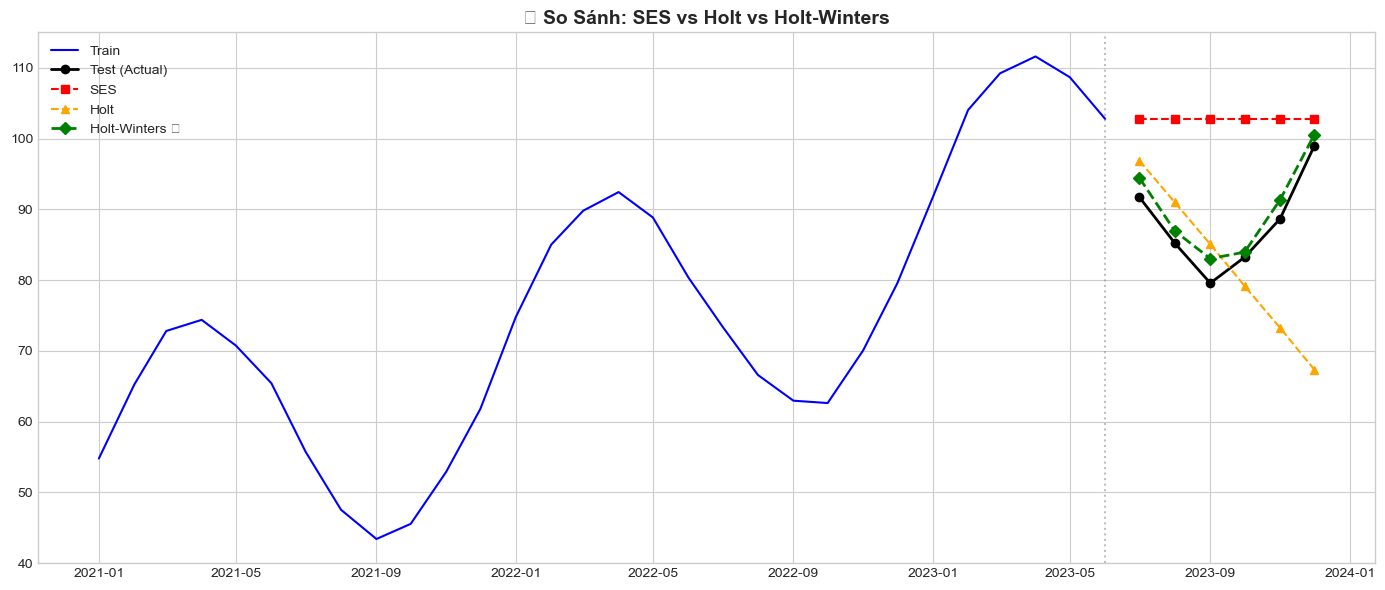


📊 Đánh giá:
📊 SES                       | MAE: 14.89 | RMSE: 16.16 | MAPE: 17.52%
📊 Holt                      | MAE: 11.25 | RMSE: 14.95 | MAPE: 12.24%
📊 Holt-Winters              | MAE: 2.15 | RMSE: 2.33 | MAPE: 2.47%

💡 Holt-Winters bắt được cả trend VÀ seasonality → Tốt nhất!


In [4]:
# Tạo dữ liệu có TREND + SEASONALITY
np.random.seed(42)
n = 365 * 3  # 3 năm, monthly
dates = pd.date_range('2021-01-01', periods=n, freq='D')
t = np.arange(n)

trend = 0.05 * t + 50
seasonal = 20 * np.sin(2 * np.pi * t / 365)
noise = np.random.normal(0, 5, n)
y = trend + seasonal + noise

data = pd.Series(y, index=dates)

# Resample monthly cho dễ nhìn
monthly = data.resample('MS').mean()
train = monthly[:-6]  # Train: tất cả trừ 6 tháng cuối
test = monthly[-6:]   # Test: 6 tháng cuối

# 3 models
ses_forecast = SimpleExpSmoothing(train).fit(optimized = True ).forecast(6)
holt_forecast = Holt(train).fit(optimized=True).forecast(6)
hw_forecast = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True).forecast(6)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Train', color='blue')
ax.plot(test.index, test, label='Test (Actual)', color='black', linewidth=2, marker='o')
ax.plot(test.index, ses_forecast, label='SES', color='red', linestyle='--', marker='s')
ax.plot(test.index, holt_forecast, label='Holt', color='orange', linestyle='--', marker='^')
ax.plot(test.index, hw_forecast, label='Holt-Winters ✅', color='green', linestyle='--', linewidth=2, marker='D')
ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.5)
ax.legend()
ax.set_title('📊 So Sánh: SES vs Holt vs Holt-Winters', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('\n📊 Đánh giá:')
evaluate(test, ses_forecast, 'SES')
evaluate(test, holt_forecast, 'Holt')
evaluate(test, hw_forecast, 'Holt-Winters')

print('\n💡 Holt-Winters bắt được cả trend VÀ seasonality → Tốt nhất!')

### 📝 Ví dụ 4: ARIMA Step by Step

  ARIMA WORKFLOW

📌 Bước 1: Kiểm tra Stationarity
   ADF p-value = 0.9170 ❌ Non-Stationary

📌 Bước 2: Differencing
   Sau d=1: ADF p-value = 0.0000 ✅ Stationary

📌 Bước 3: ACF/PACF (d=1)


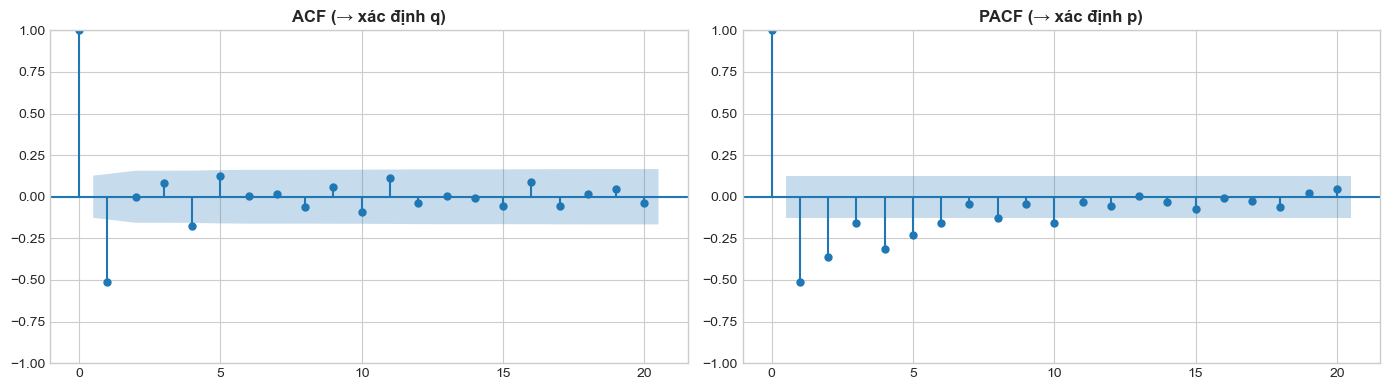


📌 Bước 4: Fit ARIMA model
   Best model: ARIMA(1, 1, 2) | AIC = 1013.38

📌 Bước 5: Forecast

📌 Bước 6: Evaluate
📊 ARIMA(1, 1, 2)            | MAE: 1.70 | RMSE: 2.12 | MAPE: 2.71%


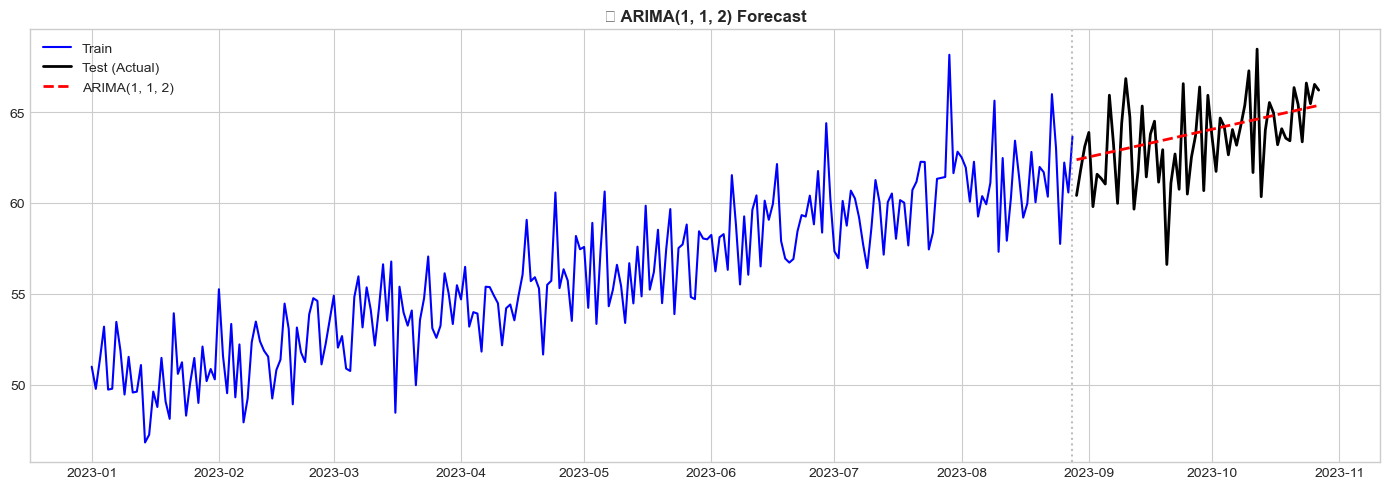

In [5]:
# ARIMA workflow hoàn chỉnh
np.random.seed(42)
n = 300
t = np.arange(n)
trend = 0.05 * t
noise = np.random.normal(0, 2, n)
y = trend + noise + 50
dates = pd.date_range('2023-01-01', periods=n, freq='D')
data = pd.Series(y, index=dates)

train = data[:240]
test = data[240:]

print('='*60)
print('  ARIMA WORKFLOW')
print('='*60)

# Bước 1: Check Stationarity
print('\n📌 Bước 1: Kiểm tra Stationarity')
p_val = adfuller(train)[1]
print(f'   ADF p-value = {p_val:.4f}', '✅ Stationary' if p_val < 0.05 else '❌ Non-Stationary')

# Bước 2: Differencing nếu cần
print('\n📌 Bước 2: Differencing')
if p_val >= 0.05:
    train_diff = train.diff().dropna()
    p_val2 = adfuller(train_diff)[1]
    print(f'   Sau d=1: ADF p-value = {p_val2:.4f}', '✅ Stationary' if p_val2 < 0.05 else '❌')
    d = 1
else:
    train_diff = train
    d = 0

# Bước 3: ACF/PACF
print(f'\n📌 Bước 3: ACF/PACF (d={d})')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, ax=axes[0], lags=20)
axes[0].set_title('ACF (→ xác định q)', fontweight='bold')
plot_pacf(train_diff, ax=axes[1], lags=20)
axes[1].set_title('PACF (→ xác định p)', fontweight='bold')
plt.tight_layout()
plt.show()

# Bước 4: Fit ARIMA
print(f'\n📌 Bước 4: Fit ARIMA model')
# Thử nhiều tổ hợp (p,d,q)
best_aic = np.inf
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train, order=(p, d, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, d, q)
                best_model = result
        except:
            continue

print(f'   Best model: ARIMA{best_order} | AIC = {best_aic:.2f}')

# Bước 5: Forecast
print(f'\n📌 Bước 5: Forecast')
forecast = best_model.forecast(steps=len(test))

# Bước 6: Evaluate
print(f'\n📌 Bước 6: Evaluate')
evaluate(test, forecast, f'ARIMA{best_order}')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='blue')
ax.plot(test.index, test, label='Test (Actual)', color='black', linewidth=2)
ax.plot(test.index, forecast, label=f'ARIMA{best_order}', color='red', linestyle='--', linewidth=2)
ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.5)
ax.legend()
ax.set_title(f'📊 ARIMA{best_order} Forecast', fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Ví dụ 5: SARIMA cho Seasonal Data

In [ ]:
# Tạo dữ liệu seasonal
np.random.seed(42)
n = 365 * 3
dates = pd.date_range('2021-01-01', periods=n, freq='D')
t = np.arange(n)

trend = 0.02 * t + 100
seasonal = 25 * np.sin(2 * np.pi * t / 365)
noise = np.random.normal(0, 5, n)
y = trend + seasonal + noise

data = pd.Series(y, index=dates)
monthly = data.resample('MS').mean()

train = monthly[:-6]
test = monthly[-6:]

print('='*60)
print('  SARIMA(p,d,q)(P,D,Q)_m')
print('='*60)

# Fit SARIMA
# Thử một vài tổ hợp
best_aic = np.inf
best_cfg = None

configs = [
    ((1,1,1), (1,1,1,12)),
    ((1,1,0), (1,1,0,12)),
    ((0,1,1), (0,1,1,12)),
    ((1,1,1), (0,1,1,12)),
    ((2,1,1), (1,1,1,12)),
]

print('\nTìm kiếm best parameters...')
for order, seasonal_order in configs:
    try:
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order)
        result = model.fit(disp=False)
        print(f'  SARIMA{order}x{seasonal_order} → AIC: {result.aic:.2f}')
        if result.aic < best_aic:
            best_aic = result.aic
            best_cfg = (order, seasonal_order)
            best_model = result
    except:
        continue

print(f'\n🏆 Best: SARIMA{best_cfg[0]}x{best_cfg[1]} | AIC: {best_aic:.2f}')

# Forecast
forecast = best_model.forecast(steps=6)
conf_int = best_model.get_forecast(steps=6).conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Train', color='blue')
ax.plot(test.index, test, label='Actual', color='black', linewidth=2, marker='o')
ax.plot(test.index, forecast, label='SARIMA Forecast', color='red', linestyle='--', linewidth=2, marker='s')
ax.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2, color='red')
ax.legend()
ax.set_title(f'📊 SARIMA{best_cfg[0]}x{best_cfg[1]} Forecast với Confidence Interval', fontweight='bold')
plt.tight_layout()
plt.show()

evaluate(test, forecast, 'SARIMA')

print('\n💡 SARIMA bắt được cả trend VÀ seasonality!')
print('💡 Vùng tô mờ = Confidence Interval (khoảng tin cậy 95%)')

### 📝 Ví dụ 6: Model Diagnostics

In [ ]:
# Diagnostic plots cho model
print('📊 Model Diagnostics - Kiểm tra chất lượng model:')
print('1. Standardized Residuals: Nên dao động ngẫu nhiên quanh 0')
print('2. Histogram: Residuals nên có phân phối chuẩn')
print('3. Q-Q Plot: Các điểm nên nằm trên đường thẳng')
print('4. Correlogram (ACF): Không nên có significant autocorrelation')

fig = best_model.plot_diagnostics(figsize=(14, 10))
plt.suptitle('🔍 Model Diagnostics', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Model TỐT khi:')
print('   ✅ Residuals ngẫu nhiên, không có pattern')
print('   ✅ Histogram gần hình chuông')
print('   ✅ Q-Q plot nằm trên đường thẳng')
print('   ✅ ACF residuals nằm trong vùng xanh')

### 📝 Ví dụ 7: So Sánh Tất Cả Models

In [ ]:
# So sánh tất cả trên cùng dữ liệu
print('\n' + '='*70)
print('  BẢNG SO SÁNH TẤT CẢ MODELS')
print('='*70)

results = {}

# SES
ses = SimpleExpSmoothing(train).fit()
results['SES'] = evaluate(test, ses.forecast(6), 'SES')

# Holt
holt = Holt(train).fit()
results['Holt'] = evaluate(test, holt.forecast(6), 'Holt')

# Holt-Winters
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
results['Holt-Winters'] = evaluate(test, hw.forecast(6), 'Holt-Winters')

# ARIMA
arima = ARIMA(train, order=(1,1,1)).fit()
results['ARIMA(1,1,1)'] = evaluate(test, arima.forecast(6), 'ARIMA(1,1,1)')

# SARIMA
results['SARIMA'] = evaluate(test, forecast, 'SARIMA (best)')

print('\n' + '='*70)
# Tìm best model
best = min(results.items(), key=lambda x: x[1]['RMSE'])
print(f'\n🏆 Best Model: {best[0]} (RMSE = {best[1]["RMSE"]:.2f})')

---
## 🏋️ BÀI TẬP THỰC HÀNH
---

### Bài 1: Exponential Smoothing (⭐ Dễ)

Với dữ liệu `retail_sales_dataset.csv`:
1. Xử lý dữ liệu, resample monthly
2. Chia train/test (80/20)
3. Fit SES, Holt, Holt-Winters
4. So sánh bằng MAE, RMSE
5. Vẽ biểu đồ so sánh

In [ ]:
# TODO: Viết code ở đây

### Bài 2: ARIMA Workflow (⭐⭐ Trung bình)

Áp dụng ARIMA workflow đầy đủ:
1. Check stationarity → Xác định d
2. Plot ACF/PACF → Xác định p, q
3. Fit ARIMA(p,d,q)
4. Kiểm tra diagnostics
5. Forecast và đánh giá

In [ ]:
# TODO: Viết code ở đây

### Bài 3: SARIMA + Confidence Interval (⭐⭐⭐ Nâng cao)

Với dữ liệu `stores_sales_forecasting.csv`:
1. Xử lý, resample monthly
2. Fit SARIMA với seasonal_period phù hợp
3. Thử ít nhất 5 tổ hợp parameters khác nhau
4. Chọn best model bằng AIC
5. Forecast 3 tháng tiếp theo với confidence interval
6. So sánh SARIMA vs Holt-Winters

In [ ]:
# TODO: Viết code ở đây

---
# 🧠 PHẦN ÔN TẬP & CỦNG CỐ KIẾN THỨC - CHƯƠNG 5

---

## 1️⃣ Nguyên Lí 80/20: 20% Kiến Thức Cốt Lõi Mang Lại 80% Giá Trị

> **Nếu bạn chỉ nhớ được 3 điều từ chương này, hãy nhớ:**

### 🔑 Kiến thức #1: Exponential Smoothing — Từ đơn giản đến phức tạp
| Phương pháp | Khi nào dùng | Ý tưởng |
|---|---|---|
| **SES** | Không trend, không seasonal | Trung bình có trọng số giảm dần |
| **Holt** | Có trend, không seasonal | SES + thành phần trend |
| **Holt-Winters** | Có trend + seasonal | Holt + thành phần seasonal |

**Quy tắc chọn nhanh:** Nhìn đồ thị → Có trend? Có seasonal? → Chọn phương pháp tương ứng.

### 🔑 Kiến thức #2: ARIMA(p, d, q) — "Bộ 3 quyền lực"
```
ARIMA(p, d, q):
  p = Số lag quá khứ ảnh hưởng (AR) → Từ PACF
  d = Số lần differencing để stationary → Từ ADF test
  q = Số lag sai số ảnh hưởng (MA)  → Từ ACF
```
**Workflow chuẩn:**
1. ADF test → Xác định **d** (thường d=0 hoặc d=1)
2. Vẽ ACF/PACF trên data đã stationary → Xác định **p, q**
3. Fit ARIMA(p,d,q) → Kiểm tra diagnostic

### 🔑 Kiến thức #3: SARIMA = ARIMA + Seasonal
```
SARIMA(p,d,q)(P,D,Q)_m
         │           │
    Non-seasonal  Seasonal (chu kỳ m)
```
- **m = 12** cho dữ liệu monthly (seasonal = 1 năm)
- **m = 7** cho dữ liệu daily (seasonal = 1 tuần)
- **Khi nào dùng:** Data có **pattern lặp lại** rõ ràng theo chu kỳ

> **Một câu tóm tắt:** *"SES cho data đơn giản, ARIMA cho data có trend, SARIMA cho data có seasonal. Workflow: ADF → ACF/PACF → Fit → Diagnostic."*

---

## 2️⃣ Mô Hình Hóa Kiến Thức: Phép Ẩn Dụ "Hệ Thống GPS"

### 🧭 Câu chuyện: ARIMA giống như GPS DẪN ĐƯỜNG

Khi bạn lái xe và GPS dự đoán **đường đi tiếp theo:**

| GPS | → ARIMA |
|---|---|
| **Vị trí hiện tại** của bạn | **AR (p):** Giá trị quá khứ ảnh hưởng hiện tại |
| GPS tính **độ lệch** so với đường dẫn dự đoán | **MA (q):** Sai số quá khứ ảnh hưởng hiện tại |
| GPS cập nhật **hướng đi** khi bạn rẽ | **d:** Differencing — tính thay đổi thay vì vị trí |
| GPS biết **giờ cao điểm** nào kẹt xe | **SARIMA:** Seasonal — pattern lặp lại |

**Exponential Smoothing giống GPS "đơn giản":**
- **SES:** GPS chỉ nhìn vị trí gần nhất → Dự đoán: "Bạn sẽ tiếp tục đi thẳng"
- **Holt:** GPS nhìn vị trí + hướng đi → Dự đoán: "Bạn đang đi về phía Đông, tiếp tục"
- **Holt-Winters:** GPS nhìn vị trí + hướng + thói quen → "Thứ 2 bạn hay đi đường này"

### 🎨 Sơ đồ chọn model:
```
         Nhìn đồ thị data
              │
     ┌────────┼────────┐
     │        │        │
   Phẳng   Có Trend   Có Trend
   (no trend, (no       + Seasonal
   no season) season)   
     │        │        │
     ▼        ▼        ▼
    SES      Holt    Holt-Winters
     │        │        │
     └────────┼────────┘
              │
        Hoặc dùng ARIMA:
              │
     ┌────────┼────────┐
     │        │        │
  ADF test  Plot     Plot
  → d=?    PACF→p   ACF→q
     │        │        │
     └────────┼────────┘
              │
         ARIMA(p,d,q)
              │
         Có seasonal?
         ┌────┴────┐
         │         │
        NO        YES
         │         │
       ARIMA    SARIMA
       (p,d,q)  (p,d,q)(P,D,Q)_m
```

---

## 3️⃣ Liên Tưởng Với Cuộc Sống

### 📈 Dự đoán giá vàng (ARIMA)
- **AR:** "Giá vàng hôm nay phụ thuộc giá mấy ngày trước" → Nhà đầu tư nhìn biểu đồ 3-5 ngày trước
- **MA:** "Sai lầm dự đoán hôm qua ảnh hưởng dự đoán hôm nay" → Điều chỉnh khi dự đoán sai
- **d:** "Đo bao nhiêu tăng/giảm mỗi ngày thay vì giá tuyệt đối" → % thay đổi

### 🏪 Đặt hàng cho cửa hàng (Exponential Smoothing)
- **SES:** "Hàng bán đều, đặt hàng dựa trên trung bình gần đây" → Cửa hàng tạp hóa
- **Holt:** "Hàng bán tăng dần, đặt nhiều hơn mỗi tháng" → Startup đang phát triển
- **Holt-Winters:** "Hàng bán tăng + mùa Tết bán gấp 3" → Cửa hàng bánh kẹo

### 🌤️ Dự báo thời tiết (SARIMA)
- **ARIMA:** Dự đoán nhiệt độ ngày mai dựa trên hôm nay + trend
- **SARIMA:** Biết rằng tháng 7 luôn nóng, tháng 12 luôn lạnh → **m=12** (seasonal period = 12 tháng)
- Kết hợp cả short-term (ngày qua ngày) và long-term (mùa trong năm)

### 💊 Liều thuốc trong máu (Exponential Smoothing)
- Uống thuốc → Nồng độ tăng vọt → Giảm dần theo thời gian → Giống **exponential decay**
- **α lớn:** Thuốc tác dụng nhanh, hết nhanh (chỉ quan tâm liều gần nhất)
- **α nhỏ:** Thuốc tác dụng chậm, kéo dài (tích lũy nhiều liều)

---

## 4️⃣ Teach to Learn — Giảng Lại Để Hiểu Sâu

### 📝 Bài tập 1: So sánh 3 phương pháp Exponential Smoothing
> Viết bảng so sánh SES vs Holt vs Holt-Winters:
> - Khi nào dùng?
> - Cần bao nhiêu parameters?
> - Ưu/nhược điểm?
> Dùng ví dụ **doanh số cửa hàng quần áo** để minh họa.

In [ ]:
# ✍️ BÀI TẬP 1: So sánh 3 phương pháp Exponential Smoothing
# Viết bảng so sánh + ví dụ doanh số cửa hàng quần áo

"""
BẢNG SO SÁNH:

| Tiêu chí        | SES               | Holt              | Holt-Winters      |
|-----------------|-------------------|-------------------|-------------------|
| Khi nào dùng?   | _______________   | _______________   | _______________   |
| Số parameters    | _______________   | _______________   | _______________   |
| Ưu điểm         | _______________   | _______________   | _______________   |
| Nhược điểm      | _______________   | _______________   | _______________   |

VÍ DỤ CỬA HÀNG QUẦN ÁO:
- Khi nào dùng SES? _______________
- Khi nào dùng Holt? _______________
- Khi nào dùng Holt-Winters? _______________
"""

In [ ]:
# ✍️ BÀI TẬP 2: Chọn model cho các tình huống thực tế
# Giải thích TẠI SAO bạn chọn model đó

"""
TÌNH HUỐNG 1: Doanh số quán cà phê mỗi ngày 
  (tăng dần, cuối tuần tăng mạnh, m=7)
  → Model: _______________
  → Tại sao: _______________

TÌNH HUỐNG 2: Nhiệt độ phòng có máy lạnh 
  (dao động quanh 25°C, không trend, không season)
  → Model: _______________
  → Tại sao: _______________

TÌNH HUỐNG 3: Giá vàng mỗi ngày 
  (trend tăng, không có mùa vụ rõ ràng)
  → Model: _______________
  → Tại sao: _______________

TÌNH HUỐNG 4: Lượng khách sạn mỗi tháng 
  (tăng dần, mùa hè đông gấp 3, m=12)
  → Model: _______________
  → Tại sao: _______________
"""

In [ ]:
# ✍️ BÀI TẬP 3: Viết Workflow hoàn chỉnh + 3 sai lầm phổ biến

"""
WORKFLOW KHI NHẬN DATA TIME SERIES MỚI:

Bước 1: _______________
Bước 2: _______________
Bước 3: _______________
Bước 4: _______________
Bước 5: _______________
Bước 6: _______________

ĐÁNH GIÁ MODEL BẰNG:
- _______________
- _______________
- _______________

3 SAI LẦM PHỔ BIẾN NHẤT KHI DÙNG ARIMA:

Sai lầm 1: _______________
  → Hậu quả: _______________
  → Cách tránh: _______________

Sai lầm 2: _______________
  → Hậu quả: _______________
  → Cách tránh: _______________

Sai lầm 3: _______________
  → Hậu quả: _______________
  → Cách tránh: _______________
"""